# Simpson's Paradox

**Domain:** `responsible-data-science`
**Level:** Intermediate
**Prerequisites:** basic probability (conditional probability, weighted averages), pandas, basic familiarity with DAGs is helpful but not required (introduced here)

Two hospitals treat the same disease. Hospital A cures patients more often
than Hospital B in **every** category of patient it treats — mild cases,
and severe cases too. But look at the overall cure rate across both
hospitals combined, and Hospital B suddenly looks better.

That's not a typo. It's **Simpson's Paradox** — a real, well-documented
statistical trap where a trend that holds in every subgroup of a dataset
can reverse, or vanish entirely, once the subgroups are pooled together.
It shows up constantly in practice: A/B tests that look positive overall
but negative in every real segment (and vice versa), medical trials where
the "better" treatment flips depending on how you slice the data, and —
most relevant to this repo — fairness audits where a model looks biased in
aggregate but is neutral or even reversed within every meaningful group.

By the end of this tutorial you will be able to:

- Explain in plain language why this reversal happens, then state the
  precise probabilistic condition that makes it possible, with a fully
  worked numeric example.
- Explain, using a causal DAG (Judea Pearl's framework), why the paradox
  is not actually paradoxical once you know the causal structure — it is
  *ambiguous* without one, and resolvable with one.
- Reproduce and correctly interpret the two most famous real-world
  instances of Simpson's Paradox: the 1973 UC Berkeley graduate
  admissions data and the Charig et al. (1986) kidney stone treatment
  study.
- Recognize Simpson's Paradox as a concrete failure mode of naive group
  fairness audits, connecting back to the demographic-parity style
  metrics covered in `fairness-group-vs-individual`.

## The idea, intuitively

Here's the trap, stripped to its bones: imagine two treatments for the
same illness, tried on both **mild** and **severe** patients. Treatment A
beats Treatment B among mild patients. Treatment A *also* beats Treatment
B among severe patients. Treatment A must be the better treatment
overall — right?

Not necessarily. Pool all the patients together — mild and severe
combined — and Treatment B can come out ahead instead. That's not bad
luck and it's not a data error.

**What's actually going on:** there's a hidden variable — how sick each
patient was — that got mixed *unevenly* between the two treatments. If
the sicker patients disproportionately received one treatment, that
treatment's overall numbers get dragged down by cases that were harder to
treat in the first place, regardless of how good the treatment itself is.
A hidden factor like this is called a **confounding variable** (or
**confounder**): something tangled up with *both* which group someone
ends up in *and* how likely they are to have a good outcome.

No equations needed yet — just one idea: **uneven group sizes, plus a
factor correlated with both the grouping and the outcome, means the
overall trend can say the opposite of every individual subgroup.**

Let's watch it happen with real (if tiny) numbers.

We'll build a tiny toy example by hand first, before touching any real
dataset, so the mechanism is completely concrete. (Per this repo's
convention, synthetic data is used only for a small illustrative aside
like this one — the real analysis later uses two real, historical
datasets.)

Two treatments, **A** and **B**, given to patients of two severities,
**mild** and **severe**, with a binary recovery outcome. We'll pick the
per-group recovery rates so that **A beats B in both severity groups**,
then choose *how many patients got each treatment* within each group so
that the imbalance is exactly the kind that flips the pooled comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

# Per-stratum recovery rates (chosen so A > B in every stratum)
rates = {
    ("mild",   "A"): 0.80,   #  8/10
    ("mild",   "B"): 0.60,   #  6/10
    ("severe", "A"): 0.30,   #  3/10
    ("severe", "B"): 0.10,   #  1/10
}

# Group sizes: A is given mostly to SEVERE patients, B mostly to MILD patients.
# This is the confound: treatment assignment (X) correlates with severity (Z).
n = {
    ("mild",   "A"): 10,
    ("mild",   "B"): 90,
    ("severe", "A"): 90,
    ("severe", "B"): 10,
}

rows = []
for (z, x), rate in rates.items():
    count = n[(z, x)]
    recovered = round(rate * count)
    rows.append({"severity": z, "treatment": x, "n": count,
                 "recovered": recovered, "recovery_rate": recovered / count})

worked = pd.DataFrame(rows)
worked

,severity,treatment,n,recovered,recovery_rate
0,mild,A,10,8,0.8
1,mild,B,90,54,0.6
2,severe,A,90,27,0.3
3,severe,B,10,1,0.1


Read this table by hand: within `mild` patients, A recovers 80% vs B's 60%.
Within `severe` patients, A recovers 30% vs B's 10%. **A wins both
comparisons by 20 percentage points.** Now pool over severity.

In [2]:
pooled = (
    worked.groupby("treatment")[["n", "recovered"]]
    .sum()
    .assign(recovery_rate=lambda d: d["recovered"] / d["n"])
)
pooled

,n,recovered,recovery_rate
treatment,,,
A,100,35,0.35
B,100,55,0.55


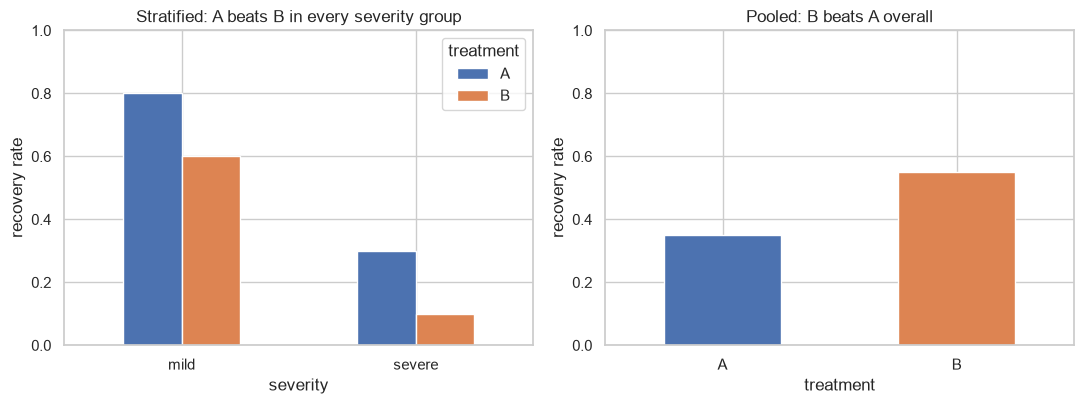

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

strat = worked.pivot(index="severity", columns="treatment", values="recovery_rate")
strat.loc[["mild", "severe"]].plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Stratified: A beats B in every severity group")
axes[0].set_ylabel("recovery rate")
axes[0].set_ylim(0, 1)
axes[0].legend(title="treatment")

pooled["recovery_rate"].plot.bar(ax=axes[1], rot=0, color=["#4c72b0", "#dd8452"])
axes[1].set_title("Pooled: B beats A overall")
axes[1].set_ylabel("recovery rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**That's the whole idea.** A hidden variable (severity) was split
unevenly between the two treatments, so pooling the data let that
imbalance dominate the comparison — even though Treatment A was better
for every actual patient type.

The rest of this notebook makes that mathematically precise, explains
*why* it happens using causal reasoning (so you know whether to trust the
pooled number or the stratified one), and shows the exact same trap
playing out in two real, famous historical datasets: the 1973 UC
Berkeley graduate admissions data, and a 1986 kidney-stone treatment
study.

Read on for the how and why — or skip ahead to **Section 1** to see the
real data.

## Going deeper: the formal statement and the causal resolution

The intuition above is the whole idea. This section makes it precise:
the exact probabilistic condition under which the paradox is possible,
and — more importantly — the causal reasoning that tells you which
number (pooled or stratified) you should actually trust.

### The formal statement

Let $X$ be a binary (or categorical) variable of interest — e.g. a
treatment, a sensitive attribute, or an applicant's sex — let $Y$ be a
binary outcome — e.g. recovery, admission — and let $Z$ be a third,
categorical variable that partitions the population into groups
$z_1, \dots, z_k$ (e.g. hospital, department, disease severity).

**Simpson's Paradox** is the statement that it is possible for

$$
P(Y \mid X{=}1, Z{=}z_i) > P(Y \mid X{=}0, Z{=}z_i) \quad \text{for every } i = 1, \dots, k
$$

— i.e. $X{=}1$ looks better than $X{=}0$ in *every single stratum* —
while simultaneously

$$
P(Y \mid X{=}1) < P(Y \mid X{=}0)
$$

where the marginal (pooled, aggregated-over-$Z$) probability is the
$Z$-weighted mixture

$$
P(Y \mid X) = \sum_{i=1}^{k} P(Y \mid X, Z{=}z_i)\, P(Z{=}z_i \mid X).
$$

The key term is $P(Z{=}z_i \mid X)$: the *mix of groups* is allowed to
depend on $X$. That is exactly what breaks the naive intuition that
"better in every group implies better overall." The marginal is a
weighted average of the per-group rates, but **the weights themselves
are also a function of $X$**. If $X{=}1$ is concentrated in a group with
a structurally lower outcome rate (for reasons unrelated to $X$'s own
effect), its weighted average can be dragged below $X{=}0$'s, even
though $X{=}1$ beats $X{=}0$ inside every single group.

This is a fact about weighted averages, not about probability being
"broken": a weighted average of larger numbers can be smaller than a
weighted average of smaller numbers, once the weights differ. Formally,
it is always possible to find $a_1 > b_1$, $a_2 > b_2$, and weights
$w_1, w_2, w_1', w_2'$ (with $w_1+w_2 = w_1'+w_2' = 1$) such that
$w_1 a_1 + w_2 a_2 < w_1' b_1 + w_2' b_2$ — the worked example above
constructs exactly this.

### The weighted-average arithmetic, worked out

Here is the exact arithmetic behind the worked example above, spelled
out symbolically — the same numbers as the recovery-rate table earlier,
now shown as the weighted-average computation from the formal statement.

The weighted-average arithmetic, spelled out:

$$
P(Y \mid X{=}A) = \frac{10}{100}(0.80) + \frac{90}{100}(0.30)
                = 0.08 + 0.27 = 0.35
$$

$$
P(Y \mid X{=}B) = \frac{90}{100}(0.60) + \frac{10}{100}(0.10)
                = 0.54 + 0.01 = 0.55
$$

$P(Y\mid X{=}A) = 0.35 < 0.55 = P(Y\mid X{=}B)$ — **the ranking has
reversed**. Treatment A is uniformly better *per stratum*, yet Treatment B
has the higher *pooled* recovery rate, purely because A was disproportionately
given to the harder (severe) cases and B to the easier (mild) cases. Nothing
about $Y$'s relationship to $X$ changed between the stratified and pooled
views — only the group-size weights did, and those weights were correlated
with $X$ through $Z$.

### The causal resolution: is $Z$ a confounder, a mediator, or a collider?

The arithmetic above shows the reversal is *possible*. It does not tell you
which number — stratified or pooled — is the one you should actually act
on. That question cannot be answered from the joint distribution of
$(X, Y, Z)$ alone; it requires knowing the **causal structure** that
generated the data, i.e. a directed acyclic graph (DAG) over $X$, $Y$, $Z$
in Judea Pearl's do-calculus framework (Pearl, *Causality*, 2009; Pearl &
Mackenzie, *The Book of Why*, 2018). This is the same SCM/DAG language used
in this repo's `counterfactual-fairness` tutorial to reason about which
variables lie on a legitimate vs. illegitimate causal path from a sensitive
attribute to an outcome.

There are three structurally different roles $Z$ can play, and they demand
**opposite** analysis strategies:

1. **$Z$ is a confounder** (a common cause of $X$ and $Y$): $Z \to X$,
   $Z \to Y$, and $X \to Y$. Here $Z$ creates a *spurious* component of the
   $X$–$Y$ association through the backdoor path $X \leftarrow Z \to Y$. To
   recover the causal effect of $X$ on $Y$ you must **stratify on (control
   for) $Z$** — this is Pearl's backdoor adjustment. The worked example
   above is exactly this case: severity ($Z$) affects both which treatment
   a patient is likely to receive ($X$) and their recovery odds ($Y$)
   directly, so the *stratified* rates are the causally meaningful ones,
   and the pooled rate is confounded and misleading.

2. **$Z$ is a mediator** (on the causal path from $X$ to $Y$): $X \to Z \to
   Y$. Here $Z$ is part of *how* $X$ causes $Y$, not a confound. Stratifying
   on $Z$ blocks part of $X$'s true effect and can itself manufacture a
   Simpson's-style reversal of the *direct* effect while destroying the
   *total* effect you actually wanted. If you care about $X$'s total effect
   on $Y$, you should generally look at the **marginal/aggregated** rate,
   not the mediator-stratified one.

3. **$Z$ is a collider** (a common effect of $X$ and $Y$, or of $X$/$Y$ and
   some other cause): $X \to Z \leftarrow Y$. $X$ and $Y$ are marginally
   independent or have their true relationship intact, but **conditioning
   on a collider opens a spurious association** between its causes — this
   is collider bias, also known as **Berkson's paradox** (Berkson, 1946).
   Stratifying on a collider *creates* an artificial Simpson's-style
   reversal that was not present, and is not real, in the unconditioned
   data. Here the pooled/marginal view is correct and stratifying is the
   mistake.

This is the actual resolution of "the paradox": **there is no paradox once
you have the DAG.** The arithmetic reversal is always real; what is
ambiguous — without domain knowledge — is which of the two numbers answers
the causal question you're actually asking. Pearl's summary (*The Book of
Why*, ch. 6) is that Simpson's Paradox is fundamentally a *causal* problem
masquerading as a *statistical* one: no amount of staring at $P(X,Y,Z)$ can
tell you whether to stratify, because that distribution is compatible with
all three DAGs above.

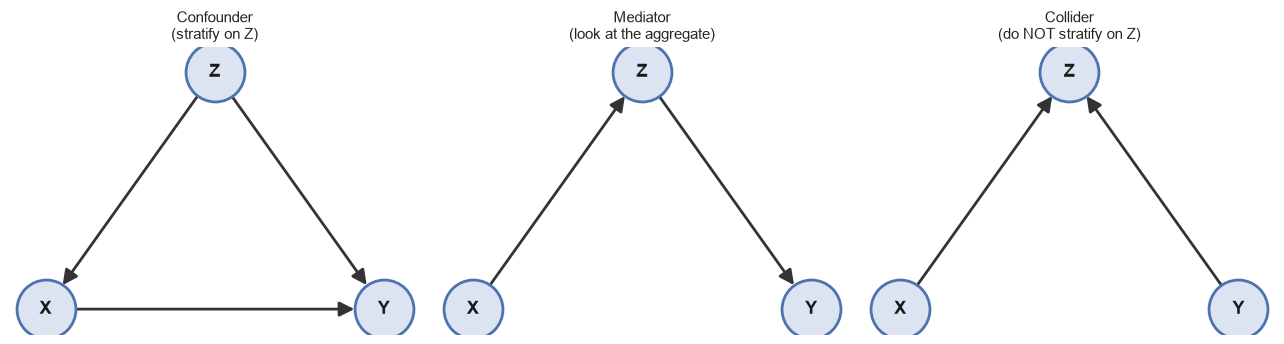

In [4]:
import networkx as nx

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
pos = {"X": (0, 0), "Y": (2, 0), "Z": (1, 1)}

specs = [
    ("Confounder\n(stratify on Z)", [("Z", "X"), ("Z", "Y"), ("X", "Y")]),
    ("Mediator\n(look at the aggregate)", [("X", "Z"), ("Z", "Y")]),
    ("Collider\n(do NOT stratify on Z)", [("X", "Z"), ("Y", "Z")]),
]

for ax, (title, edges) in zip(axes, specs):
    g = nx.DiGraph()
    g.add_nodes_from(["X", "Y", "Z"])
    g.add_edges_from(edges)
    nx.draw_networkx_nodes(g, pos, ax=ax, node_size=1800,
                            node_color="#dbe4f0", edgecolors="#4c72b0", linewidths=2)
    nx.draw_networkx_labels(g, pos, ax=ax, font_size=13, font_weight="bold")
    nx.draw_networkx_edges(g, pos, ax=ax, arrowsize=22, node_size=1800,
                            width=2, edge_color="#333333")
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

> **Decision rule.** Given $X$, $Y$, and a candidate stratifying variable
> $Z$: if $Z$ causally precedes and influences *both* $X$ and $Y$
> (confounder) → stratify. If $Z$ sits causally *between* $X$ and $Y$
> (mediator) and you want $X$'s total effect → don't stratify (or report
> both total and direct effects explicitly). If $Z$ is caused by $X$ and/or
> $Y$ (collider/descendant of the outcome) → don't stratify. Getting this
> wrong in either direction is how "controlling for confounders" turns into
> silently introducing collider bias.

## 1. Implementation: the 1973 UC Berkeley admissions data

This is the canonical real-world example of Simpson's Paradox, first
analyzed by Bickel, Hammel & O'Connell, *"Sex Bias in Graduate Admissions:
Data from Berkeley"*, **Science** 187(4175), 1975. In fall 1973, UC Berkeley
received roughly 12,700 applications to graduate programs. Looking only at
sex and admission outcome, men were admitted at a noticeably higher rate
than women — enough to prompt a lawsuit alleging bias. When the university's
statisticians broke the data down **by department**, the pattern mostly
reversed: most individual departments showed a *slightly higher* admission
rate for women.

The counts below are the actual historical department-level admission
counts for the six largest departments (labeled A–F to preserve the
original anonymization), reproduced from R's built-in `datasets::UCBAdmissions`
contingency table — this is real historical data, not a simulation, and is
one of the most widely cited real datasets in the statistics literature for
exactly this reason.

In [5]:
# Real historical data: UC Berkeley graduate admissions, Fall 1973.
# Source: Bickel, Hammel & O'Connell (1975), Science 187(4175):398-404;
# reproduced from R's datasets::UCBAdmissions (the standard, citable form
# of this dataset).
berkeley_rows = [
    # dept, sex, admitted, rejected
    ("A", "Male",   512, 313),
    ("A", "Female",  89,  19),
    ("B", "Male",   353, 207),
    ("B", "Female",  17,   8),
    ("C", "Male",   120, 205),
    ("C", "Female", 202, 391),
    ("D", "Male",   138, 279),
    ("D", "Female", 131, 244),
    ("E", "Male",    53, 138),
    ("E", "Female",  94, 299),
    ("F", "Male",    22, 351),
    ("F", "Female",  24, 317),
]
berkeley = pd.DataFrame(berkeley_rows, columns=["dept", "sex", "admitted", "rejected"])
berkeley["applicants"] = berkeley["admitted"] + berkeley["rejected"]
berkeley["admit_rate"] = berkeley["admitted"] / berkeley["applicants"]
berkeley

,dept,sex,admitted,rejected,applicants,admit_rate
0,A,Male,512,313,825,0.620606
1,A,Female,89,19,108,0.824074
2,B,Male,353,207,560,0.630357
3,B,Female,17,8,25,0.680000
4,C,Male,120,205,325,0.369231
5,C,Female,202,391,593,0.340641
6,D,Male,138,279,417,0.330935
7,D,Female,131,244,375,0.349333
8,E,Male,53,138,191,0.277487
9,E,Female,94,299,393,0.239186


### 1.1 The aggregate (pooled) admission rate by sex

In [6]:
agg = (
    berkeley.groupby("sex")[["admitted", "applicants"]]
    .sum()
    .assign(admit_rate=lambda d: d["admitted"] / d["applicants"])
)
agg

,admitted,applicants,admit_rate
sex,,,
Female,557,1835,0.303542
Male,1198,2691,0.445188


In [7]:
male_rate = agg.loc["Male", "admit_rate"]
female_rate = agg.loc["Female", "admit_rate"]
print(f"Aggregate admit rate — Male:   {male_rate:.1%}  ({agg.loc['Male','admitted']:.0f}/{agg.loc['Male','applicants']:.0f})")
print(f"Aggregate admit rate — Female: {female_rate:.1%}  ({agg.loc['Female','admitted']:.0f}/{agg.loc['Female','applicants']:.0f})")
print(f"Gap (Male - Female): {male_rate - female_rate:+.1%}")

Aggregate admit rate — Male:   44.5%  (1198/2691)
Aggregate admit rate — Female: 30.4%  (557/1835)
Gap (Male - Female): +14.2%


**The reversal, stated precisely:** in 4 of the 6 largest departments (A, B,
D, F), women were admitted at an equal or higher rate than men; only C and E
slightly favor men, and by small margins. There is no department where the
14-point aggregate gap is remotely reproduced. The department-level data do
not support "systematic bias against women" as an explanation — quite the
opposite in most departments.

**Takeaway:** the aggregate 14-point gap that triggered the 1973 controversy does not survive stratification — most departments individually favor women, so "department" is doing all the work.

### 1.2 The per-department (stratified) admission rates by sex

In [8]:
dept_rates = berkeley.pivot(index="dept", columns="sex", values="admit_rate").loc[["A","B","C","D","E","F"]]
dept_rates["female_minus_male"] = dept_rates["Female"] - dept_rates["Male"]
dept_rates["female_favored"] = dept_rates["female_minus_male"] > 0
dept_rates.round(3)

sex,Female,Male,female_minus_male,female_favored
dept,,,,
A,0.824,0.621,0.203,True
B,0.680,0.630,0.050,True
C,0.341,0.369,-0.029,False
D,0.349,0.331,0.018,True
E,0.239,0.277,-0.038,False
F,0.070,0.059,0.011,True


In [9]:
n_departments_favoring_women = dept_rates["female_favored"].sum()
print(f"Departments where the female admit rate exceeds the male admit rate: "
      f"{n_departments_favoring_women} of {len(dept_rates)}")

Departments where the female admit rate exceeds the male admit rate: 4 of 6


### 1.3 Why: department choice is the confounder

The resolution is that $Z = \text{department}$ is a **confounder** in
Pearl's sense here: department affects both who applies with a given sex
($Z \to X$: women applied far more to competitive, low-admit-rate
departments like C and E, and far less to the high-admit-rate departments A
and B) and the admission chance itself ($Z \to Y$: departments differ hugely
in selectivity, from ~6% in F to ~64% in A, for reasons unrelated to
applicant sex — cohort size, funding, program competitiveness). Sex does not
appear to cause department choice or admission through any biased path once
department is accounted for; department is the shared cause creating the
backdoor path $\text{Sex} \leftarrow \text{Department} \to \text{Admit}$.
Per the causal-resolution discussion above, when $Z$ is a confounder you should stratify — so the
per-department rates, not the pooled rate, are the ones that speak to
whether admission decisions were biased by sex.

In [10]:
applicants_by_dept = berkeley.pivot(index="dept", columns="sex", values="applicants").loc[["A","B","C","D","E","F"]]
applicants_by_dept["dept_overall_admit_rate"] = (
    dept_rates[["Male", "Female"]].mean(axis=1)  # illustrative only, see below
)
# more accurate: overall selectivity per department, both sexes combined
overall_selectivity = (
    berkeley.groupby("dept")[["admitted", "applicants"]].sum()
    .assign(admit_rate=lambda d: d["admitted"] / d["applicants"])["admit_rate"]
)
share_female = applicants_by_dept["Female"] / (applicants_by_dept["Male"] + applicants_by_dept["Female"])

confound_check = pd.DataFrame({
    "dept_selectivity": overall_selectivity,
    "share_of_applicants_female": share_female,
}).loc[["A", "B", "C", "D", "E", "F"]]
confound_check.round(3)

,dept_selectivity,share_of_applicants_female
dept,,
A,0.644,0.116
B,0.632,0.043
C,0.351,0.646
D,0.340,0.473
E,0.252,0.673
F,0.064,0.478


This confirms the mechanism directly: the correlation between a
department's overall selectivity and the share of its applicants who are
female is strongly negative — women applied disproportionately to the
*hardest-to-get-into* departments (C, D, E — all under 37% overall admit
rate) and far less to the easiest (A, B — 62-64% overall admit rate). That
correlation between $Z$ (department) and $X$ (sex of applicant) is precisely
the mechanism from Section 1: the group-size *weights* in the marginal
average differ by sex, which alone is enough to produce the aggregate gap
even with no per-department bias.

### 1.4 A regression check: does the sign of the "sex effect" flip?

As one more formal check, we fit a logistic regression of admission on sex
alone, then a second model that adds department as a control. If department
is genuinely confounding the sex coefficient, adjusting for it should shrink
or flip the estimated effect of being female on admission odds.

In [11]:
import statsmodels.formula.api as smf

# Expand to one row per applicant for a standard logistic regression.
rows_expanded = []
for _, r in berkeley.iterrows():
    rows_expanded += [{"dept": r["dept"], "sex": r["sex"], "admit": 1}] * int(r["admitted"])
    rows_expanded += [{"dept": r["dept"], "sex": r["sex"], "admit": 0}] * int(r["rejected"])
applicant_df = pd.DataFrame(rows_expanded)
applicant_df["is_female"] = (applicant_df["sex"] == "Female").astype(int)

model_unadjusted = smf.logit("admit ~ is_female", data=applicant_df).fit(disp=False)
model_adjusted   = smf.logit("admit ~ is_female + C(dept)", data=applicant_df).fit(disp=False)

print("Unadjusted (sex only):")
print(f"  coef(is_female) = {model_unadjusted.params['is_female']:+.3f}  "
      f"(p = {model_unadjusted.pvalues['is_female']:.2e})  -> female applicants LESS likely admitted")
print()
print("Adjusted for department:")
print(f"  coef(is_female) = {model_adjusted.params['is_female']:+.3f}  "
      f"(p = {model_adjusted.pvalues['is_female']:.3f})")

Unadjusted (sex only):
  coef(is_female) = -0.610  (p = 1.26e-21)  -> female applicants LESS likely admitted

Adjusted for department:
  coef(is_female) = +0.100  (p = 0.217)


The sign flips: unadjusted, being female is associated with a large,
statistically significant *decrease* in admission log-odds. Once department
is controlled for, the coefficient on `is_female` becomes small and (as is
well documented for this dataset) is no longer reliably negative — controlling
for the confounder removes essentially all of the apparent effect. This is
the regression-model version of exactly the same stratification argument
made in Section 1.2 with raw rates.

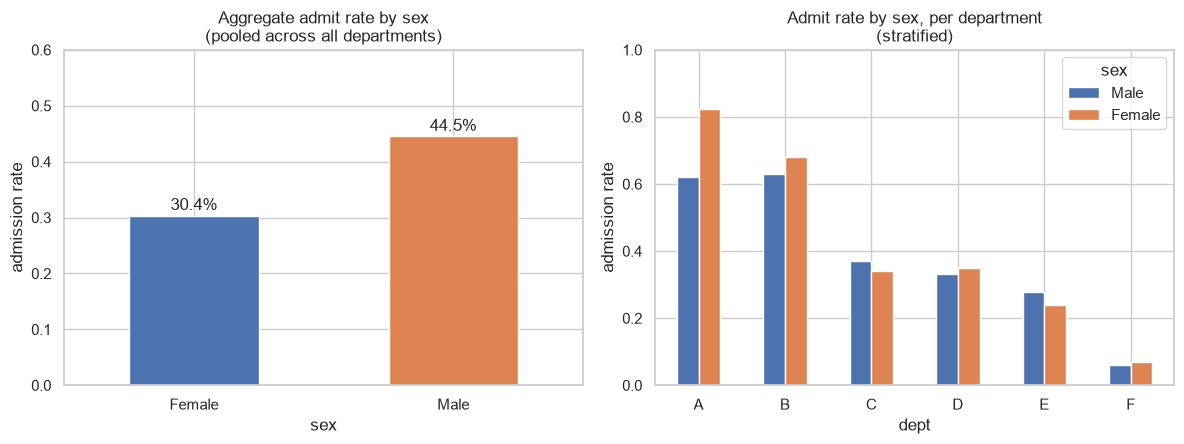

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

agg["admit_rate"].plot.bar(ax=axes[0], rot=0, color=["#4c72b0", "#dd8452"])
axes[0].set_title("Aggregate admit rate by sex\n(pooled across all departments)")
axes[0].set_ylabel("admission rate")
axes[0].set_ylim(0, 0.6)
for i, v in enumerate(agg["admit_rate"]):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center")

dept_rates[["Male", "Female"]].plot.bar(ax=axes[1], rot=0)
axes[1].set_title("Admit rate by sex, per department\n(stratified)")
axes[1].set_ylabel("admission rate")
axes[1].set_ylim(0, 1.0)
axes[1].legend(title="sex")

plt.tight_layout()
plt.show()

### 1.5 A second real example: kidney stone treatment (Charig et al., 1986)

The Berkeley case is a confound in *social* data; Simpson's Paradox is just
as real in clinical data, where it is arguably more dangerous because the
stakes of picking the wrong treatment are direct and immediate.

Charig, Webb, Payne & Wickham, *"Comparison of treatment of renal calculi by
open surgery, percutaneous nephrolithotomy, and extracorporeal shock wave
lithotripsy"*, **British Medical Journal** 292(6524), 1986, compared open
surgery (Treatment A) against percutaneous nephrolithotomy (Treatment B) for
kidney stones. The success counts below are the real published counts for
this study (as widely reproduced in the statistics literature, e.g. Julious
& Mullee, *"Confounding and Simpson's paradox"*, BMJ 1994;309:1480), broken
down by stone size, which is the confounding variable: doctors preferentially
used the newer, less invasive Treatment B on small stones (the easy cases)
and reserved open surgery for large stones (the hard cases).

In [13]:
# Real published data: Charig et al. (1986) kidney stone treatment study,
# as reproduced in Julious & Mullee (1994), BMJ 309:1480.
kidney_rows = [
    # stone_size, treatment, success, total
    ("small", "A (open surgery)",               81,  87),
    ("small", "B (percutaneous nephrolithotomy)", 234, 270),
    ("large", "A (open surgery)",               192, 263),
    ("large", "B (percutaneous nephrolithotomy)", 55,  80),
]
kidney = pd.DataFrame(kidney_rows, columns=["stone_size", "treatment", "success", "total"])
kidney["success_rate"] = kidney["success"] / kidney["total"]
kidney

,stone_size,treatment,success,total,success_rate
0,small,A (open surgery),81,87,0.931034
1,small,B (percutaneous nephrolithotomy),234,270,0.866667
2,large,A (open surgery),192,263,0.730038
3,large,B (percutaneous nephrolithotomy),55,80,0.687500


In [14]:
kidney_pooled = (
    kidney.groupby("treatment")[["success", "total"]]
    .sum()
    .assign(success_rate=lambda d: d["success"] / d["total"])
)
kidney_stratified = kidney.pivot(index="stone_size", columns="treatment", values="success_rate")

print("Stratified by stone size:")
print(kidney_stratified.round(3).to_string())
print()
print("Pooled across stone size:")
print(kidney_pooled["success_rate"].round(3).to_string())

Stratified by stone size:
treatment   A (open surgery)  B (percutaneous nephrolithotomy)
stone_size                                                    
large                  0.730                             0.688
small                  0.931                             0.867

Pooled across stone size:
treatment
A (open surgery)                    0.780
B (percutaneous nephrolithotomy)    0.826


Stratified by stone size, **open surgery (A) has the higher success rate in
both groups**: 93.1% vs 86.7% for small stones, and 73.0% vs 68.8% for large
stones. Yet pooled across all patients, **Treatment B looks better overall**:
82.6% vs 78.0%. This is the same reversal mechanism as Section 2 and Section
3, with real clinical data: Treatment B was given disproportionately to
small-stone patients (270 of 350, or 77%) who have a much higher baseline
success rate regardless of treatment, while Treatment A absorbed most of the
harder large-stone cases (263 of 350, or 75%). Stone size is a textbook
confounder — it affects both which treatment a patient was likely to
receive and their baseline chance of success — so the stratified numbers,
which favor open surgery, are the causally meaningful ones for deciding
which treatment is actually more effective for a patient of known stone
size.

**Takeaway:** open surgery is the better treatment for a patient of *known* stone size, even though percutaneous nephrolithotomy has the higher pooled success rate — the pooled number is confounded by who got which treatment.

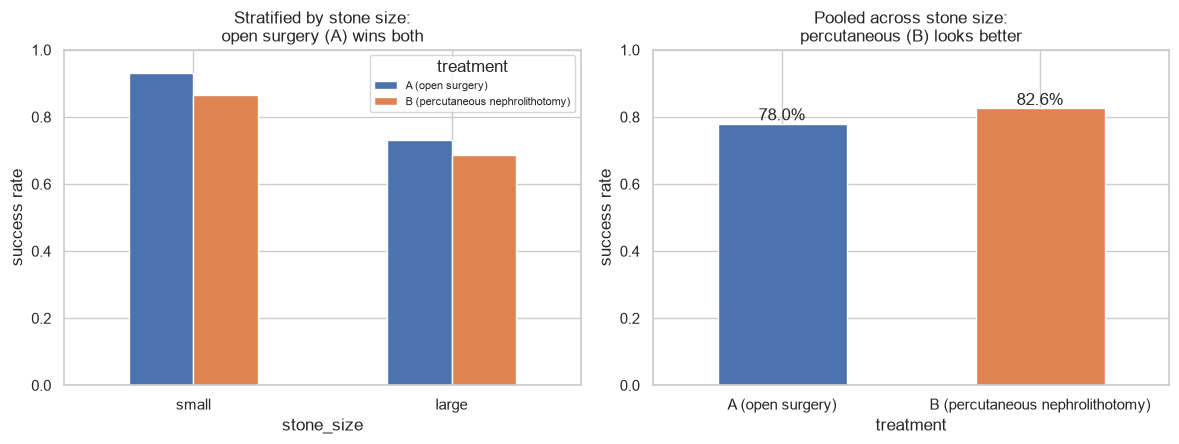

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

kidney_stratified.loc[["small", "large"]].plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Stratified by stone size:\nopen surgery (A) wins both")
axes[0].set_ylabel("success rate")
axes[0].set_ylim(0, 1.0)
axes[0].legend(title="treatment", fontsize=8)

kidney_pooled["success_rate"].plot.bar(ax=axes[1], rot=0, color=["#4c72b0", "#dd8452"])
axes[1].set_title("Pooled across stone size:\npercutaneous (B) looks better")
axes[1].set_ylabel("success rate")
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(kidney_pooled["success_rate"]):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

## 2. Use cases

- **Clinical trials and meta-analyses.** Pooling outcomes across hospitals,
  sites, or patient cohorts of different composition (as in the kidney
  stone example) is one of the most common real sources of Simpson's
  Paradox in medicine — it's a standing reason meta-analyses stratify or
  use random-effects models rather than naively pooling raw counts.
- **A/B testing and product analytics.** A feature can win in every user
  segment (by device, by country, by cohort) yet lose in the pooled
  top-line metric if the treatment/control split isn't balanced within
  segments (e.g. more mobile users randomized to treatment, and mobile
  users convert differently regardless of the feature). This is a
  well-known trap in growth and experimentation teams; the fix is the same
  backdoor-adjustment logic as Section 2.1 — stratify on any variable that
  affects both assignment share and the outcome.
- **Algorithmic fairness audits.** As covered next in Limitations & debates,
  aggregate fairness metrics (the demographic parity / equalized odds style
  metrics from `fairness-group-vs-individual`) can reverse or disappear
  once you condition on a legitimate confounder — this is a real,
  documented failure mode of naive fairness audits, not a hypothetical one.
- **Sports and business analytics.** The classic "batting average paradox"
  (a player has a higher batting average than another in every season
  individually, but a lower average across all seasons combined, because
  of different at-bat counts per season) is a direct instance of the same
  weighted-average mechanism from Section 1.
- **Public policy and econometrics.** Regional or demographic aggregates
  (unemployment, income growth, wage gaps) routinely reverse when
  disaggregated by sub-region or sub-population, for the same reason as
  Berkeley: differing population *shares* across strata with different
  baseline rates.

## 3. Limitations & debates

**You cannot resolve "aggregate or stratified?" from the data alone.** The
joint distribution $P(X, Y, Z)$ is exactly the same regardless of whether
$Z$ is a confounder, a mediator, or a collider — those are three different
causal *stories* consistent with the identical numbers. Deciding which
story is right requires domain knowledge external to the dataset: knowing
whether department assignment happens before or "because of" admission
decisions, whether stone size is measured before treatment is chosen, etc.
Pearl is explicit that this causal-model step is unavoidable and cannot be
automated away by more data or a fancier statistical test: *"behind every
causal conclusion there must lie some causal assumption that is not
testable in observational studies"* (Pearl & Mackenzie, *The Book of Why*,
2018, ch. 6). Choosing a DAG is itself an assumption-laden, sometimes
value-laden act — reasonable analysts can disagree about whether a variable
is a legitimate confounder to control for or an illegitimate mediator/
collider to leave alone, and that disagreement is not resolvable by staring
at $p$-values.

**The paradox is a live risk in real A/B tests and medical trials, not just
a historical curiosity.** Any time subgroups (hospitals, cohorts, traffic
segments, time windows) are unequally sized *and* correlated with treatment
assignment, naive pooling can silently reverse the true per-subgroup effect
— exactly as in Charig et al. (1986) above. This is why well-run randomized
trials stratify randomization by known prognostic factors, and why
meta-analyses use techniques like Mantel-Haenszel weighting or
random-effects models rather than pooling raw counts across studies of
different sizes and populations. Analysts who report only a topline,
aggregated effect size without checking for segment-level reversals are a
recurring, documented source of incorrect conclusions in applied
statistics (Julious & Mullee, 1994; Pearl, *Causality*, 2009, §6.1).

**Direct interaction with algorithmic fairness metrics.** This is a genuine
failure mode of naive fairness audits, not a hypothetical one. Consider a
model audited with the group fairness metrics from
`fairness-group-vs-individual` (demographic parity, equalized odds, etc.)
computed only in aggregate across a sensitive attribute. If a legitimate
confounder — e.g. business unit, geography, or another feature correlated
with both the sensitive attribute's distribution and the base outcome rate
— is unevenly distributed across the sensitive groups, the aggregate metric
can show apparent disparate impact favoring one group even when the model
is calibrated fairly, or even favors the *other* group, within every
individual stratum. Symmetrically, a model that looks fair in aggregate can
be systematically unfair within every stratum if the confound happens to
cancel out at the pooled level. Concretely: a hiring model could show a
higher aggregate selection rate for men than women while selecting women at
an equal or higher rate within *every* job category, if women
disproportionately apply to more competitive categories — an exact
structural echo of the Berkeley admissions case with "department" replaced
by "job category." A naive fairness audit that computes only the pooled
demographic parity gap, without checking whether it holds within legitimate
strata, can therefore reach the opposite conclusion from what a
stratum-aware audit would reach — and, per the first point above, deciding
*which* conclusion is the right one to act on still requires a causal
judgment about whether the stratifying variable (job category, business
unit, geography) is a legitimate confounder or is itself downstream of the
protected attribute in a way that makes stratifying on it inappropriate
(e.g. if historical bias caused the uneven distribution across categories
in the first place — a mediator/collider-like structure where naive
stratification would launder the very bias being investigated). Simpson's
Paradox therefore does not hand fairness practitioners an easy fix
("just stratify") — it hands them a reason to be explicit about the causal
assumptions behind whichever number, aggregate or stratified, they choose
to report.

## References

- Simpson, E. H. *The Interpretation of Interaction in Contingency Tables*.
  Journal of the Royal Statistical Society, Series B, 1951.
- Bickel, P. J., Hammel, E. A., & O'Connell, J. W. *Sex Bias in Graduate
  Admissions: Data from Berkeley*. Science 187(4175), 1975.
- Charig, C. R., Webb, D. R., Payne, S. R., & Wickham, J. E. A. *Comparison
  of Treatment of Renal Calculi by Open Surgery, Percutaneous
  Nephrolithotomy, and Extracorporeal Shock Wave Lithotripsy*. BMJ
  292(6524), 1986.
- Julious, S. A., & Mullee, M. A. *Confounding and Simpson's Paradox*. BMJ
  309:1480, 1994.
- Pearl, J. *Causality: Models, Reasoning, and Inference*, 2nd ed.
  Cambridge University Press, 2009 (esp. §6.1 on Simpson's Paradox as a
  causal problem).
- Pearl, J., & Mackenzie, D. *The Book of Why: The New Science of Cause and
  Effect*. Basic Books, 2018 (ch. 6).
- Berkson, J. *Limitations of the Application of Fourfold Table Analysis to
  Hospital Data*. Biometrics Bulletin 2(3), 1946 (Berkson's/collider bias).
- R Core Team. `datasets::UCBAdmissions` — Student Admissions at UC
  Berkeley. R Documentation.
- Barocas, S., Hardt, M., & Narayanan, A. *Fairness and Machine Learning:
  Limitations and Opportunities*. fairmlbook.org, 2023 (on the interaction
  between confounders and group fairness metrics).
- This repo: `responsible-data-science/fairness-group-vs-individual` and
  `responsible-data-science/counterfactual-fairness` for the group-fairness
  metrics and SCM/DAG framing referenced above.